# Pancancer enrichment analysis step 3: Make figures from Reactome data

## Setup

In [1]:
import cptac
import cptac.utils as ut
import os
import datetime
import altair as alt
import numpy as np
import pandas as pd
import operator
import IPython.display

In [2]:
TIME_START = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')

STEP1_DIR = "step1_outputs"
STEP1_FILE = "tumor_change_20200529_195104_10000_perm.tsv"
STEP1_FILE_PATH = os.path.join(STEP1_DIR, STEP1_FILE)

STEP2_DIR = "step2_outputs"
STEP2_FILE = "enrichment_20200609_171630_from_tumor_change_20200529_195104_10000_perm.tsv"
STEP2_FILE_PATH = os.path.join(STEP2_DIR, STEP2_FILE)

STEP3_DIR = "step3_outputs"

if not os.path.isdir(STEP3_DIR):
    os.mkdir(STEP3_DIR)
    
MSV = 0.5 # Simplified expression value for marginally significant proteins

In [3]:
# Altair options
# alt.data_transformers.disable_max_rows()
# alt.data_transformers.enable('json')

## Read in data from steps 1 and 2

In [4]:
all_expression_data = pd.read_csv(STEP1_FILE_PATH, sep="\t", index_col=0)

# Make a column where all increases are +1 and all decreases 
# are -1, because these are ratioed abundances, so we can't 
# compare magnitudes between genes--we can only compare whether 
# there was a change, and whether it was positive or negative
all_expression_data = all_expression_data.assign(simplified_change=np.nan)

# adj p < 0.05 and change > 1 => +1
all_expression_data.loc[
    (all_expression_data["change"] > 0) & (all_expression_data["adj_p"] < 0.05), 
    "simplified_change"
] = 1

# adj p >= 0.05 and change > 1 => +0.5
all_expression_data.loc[(all_expression_data["change"] > 0) & (all_expression_data["adj_p"] >= 0.05),
    "simplified_change"
] = MSV

# change == 0 => 0
all_expression_data.loc[
    all_expression_data["change"] == 0,
    "simplified_change"
] = 0

# adj p >= 0.05 and change < 1 => -0.5
all_expression_data.loc[(all_expression_data["change"] < 0) & (all_expression_data["adj_p"] >= 0.05), 
    "simplified_change"
] = -MSV

# adj p < 0.05 and change < 1 => -1
all_expression_data.loc[
    (all_expression_data["change"] < 0) & (all_expression_data["adj_p"] < 0.05),
    "simplified_change"
] = -1

# Select just the proteins where we chose to reject the null hypothesis of no change
expression_data = all_expression_data[all_expression_data["reject_null"]]

all_expression_data

,cancer_type,protein,change,P_val,adj_p,reject_null,protein_str,simplified_change
0,ccrcc,"('A1BG', 'NP_570602.2')",0.282928,0.0000,0.000000,True,A1BG,1.0
1,ccrcc,"('A1CF', 'NP_620310.1')",-0.551358,0.0000,0.000000,True,A1CF,-1.0
2,ccrcc,"('A2M', 'NP_000005.2')",0.595512,0.0000,0.000000,True,A2M,1.0
3,ccrcc,"('A4GALT', 'NP_001304967.1')",0.479410,0.1735,0.214310,False,A4GALT,0.5
4,ccrcc,"('AAAS', 'NP_056480.1')",0.173579,0.0000,0.000000,True,AAAS,1.0
5,ccrcc,"('AACS', 'NP_076417.2')",-0.215967,0.0000,0.000000,True,AACS,-1.0
6,ccrcc,"('AADAC', 'NP_001077.2')",0.147423,0.7481,0.784497,False,AADAC,0.5
7,ccrcc,"('AADAT', 'NP_001273612.1')",-1.818291,0.0000,0.000000,True,AADAT,-1.0
8,ccrcc,"('AAED1', 'NP_714542.1')",0.426052,0.0000,0.000000,True,AAED1,1.0
9,ccrcc,"('AAGAB', 'NP_078942.3')",-0.070117,0.0009,0.001554,True,AAGAB,-1.0


In [5]:
enrichment_data = pd.read_csv(STEP2_FILE_PATH, sep="\t", index_col=0)
enrichment_data

,pathway_id,cancer_type,mean_expr,url,name,pathway_times_enriched,pathway_avg_rank,entities_pValue,entities_fdr,cancer_rank_pval
0,R-HSA-6798695,ccrcc,0.233503,https://reactome.org/PathwayBrowser/#/R-HSA-67...,Neutrophil degranulation,8,1.000,3.467008e-03,8.426404e-01,1.0
1,R-HSA-6798695,colon,-0.134831,https://reactome.org/PathwayBrowser/#/R-HSA-67...,Neutrophil degranulation,8,1.000,6.216916e-12,1.500142e-08,1.0
2,R-HSA-6798695,endometrial,0.288515,https://reactome.org/PathwayBrowser/#/R-HSA-67...,Neutrophil degranulation,8,1.000,1.403496e-03,8.219205e-01,1.0
3,R-HSA-6798695,gbm,0.166227,https://reactome.org/PathwayBrowser/#/R-HSA-67...,Neutrophil degranulation,8,1.000,2.129677e-03,8.037977e-01,1.0
4,R-HSA-6798695,hnscc,0.133159,https://reactome.org/PathwayBrowser/#/R-HSA-67...,Neutrophil degranulation,8,1.000,3.649260e-03,8.329209e-01,1.0
5,R-HSA-6798695,lscc,-0.407595,https://reactome.org/PathwayBrowser/#/R-HSA-67...,Neutrophil degranulation,8,1.000,1.637558e-03,8.726502e-01,1.0
6,R-HSA-6798695,luad,-0.410000,https://reactome.org/PathwayBrowser/#/R-HSA-67...,Neutrophil degranulation,8,1.000,1.800932e-04,4.412282e-01,1.0
7,R-HSA-6798695,ovarian,-0.303754,https://reactome.org/PathwayBrowser/#/R-HSA-67...,Neutrophil degranulation,8,1.000,3.532076e-05,8.660650e-02,1.0
8,R-HSA-6791226,ccrcc,0.699422,https://reactome.org/PathwayBrowser/#/R-HSA-67...,Major pathway of rRNA processing in the nucleo...,8,2.875,3.132093e-02,8.426404e-01,4.0
9,R-HSA-6791226,colon,0.771429,https://reactome.org/PathwayBrowser/#/R-HSA-67...,Major pathway of rRNA processing in the nucleo...,8,2.875,2.825057e-07,1.376497e-04,2.0


## Figure 1: Bubble plot

In [6]:
enrichment_data = enrichment_data.assign(
    rank_size=1 / enrichment_data["cancer_rank_pval"],
    avg_rank_size=1 / enrichment_data["pathway_avg_rank"],
    avg_rank_label=enrichment_data["pathway_avg_rank"].astype(str))

# Take care of duplicates for the upper plot
enrichment_data["avg_rank_label"] = enrichment_data["avg_rank_label"].where(
    cond=~(enrichment_data.duplicated(subset=["cancer_type", "avg_rank_label"], keep="first")),
    other=" " + enrichment_data["avg_rank_label"])

In [9]:
individual = alt.Chart(enrichment_data).mark_circle().encode(
    x=alt.X(
        "name:N",
        sort=enrichment_data["name"].values,
        axis=alt.Axis(
            labelAngle=-30,
            labelFontSize=12,
            labelLimit=500,
            title="",
            titleFontSize=12
        )
    ),
    y=alt.Y(
        "cancer_type:N",
        axis=alt.Axis(
            title="Cancer type",
            titleFontSize=12
        ),
    ),
    size=alt.Size(
        "rank_size:Q",
        legend=None
    ),
    color=alt.Color(
        "mean_expr:Q",
        scale=alt.Scale(
            scheme="blueorange"
        ),
        legend=alt.Legend(
            title="Pathway tumor expression"
        )
    )
).properties(
    width=400,
    height=300
)

aggregate = alt.Chart(enrichment_data).mark_circle().encode(
    x=alt.X(
        "avg_rank_label:N",
        sort=enrichment_data["avg_rank_label"].values,
        axis=alt.Axis(
            labelAngle=-30,
            labelFontSize=12,
            labelLimit=500,
            title="Overall rank of pathway",
            titleFontSize=12
        )
    ),
    size=alt.Size(
        "avg_rank_size:Q",
        legend=None
    ),
).properties(
    width=400,
    title="Reactome enrichment analysis"
)

alt.vconcat(aggregate, individual).configure_axis(
    grid=True
).configure_title(
    fontSize=16,
    offset=20
)

alt.VConcatChart(...)

## Figure 2: Expression of proteins in the neutrophil degranulation pathway

In [8]:
# Get the ID the top expessed pathway
neutro_pathway_ids = enrichment_data.\
    loc[enrichment_data["name"] == "Neutrophil degranulation", "pathway_id"].\
    unique()

if len(neutro_pathway_ids) != 1:
    raise ValueError("Multiple pathways found.")
    
neutro_pathway_id = neutro_pathway_ids[0]

### A: With proteins in different orders for the up and down categories

In [9]:
def expr_heatmap(expr_data, enrich_data, pathway_id, up_or_down, max_p, x_title=True):
    """Make a heatmap with proteins on the X axis, cancer types on the Y 
    axis, and the color reflecting the expression of that protein in that
    cancer type.
    
    Parameters:
    expr_data (pandas.DataFrame): A dataframe with columns "cancer_type", "protein_str", "adj_p", and "simplified_change".
    enrich_data (pandas.DataFrame): A dataframe with columns "cancer_type" and "mean_expr" (i.e. mean expression for the pathway of interest).
    pathway_id (str): The Reactome pathway id for the pathway you want the heatmap for.
    up_or_down (str): Either "up" or "down"; whether to plot cancers where the pathway is up, or where it's down.
    max_p (float): The minimum p value for a protein to be included on the plot. If max_p > 0.05, then proteins with 0.05 <= p < max_p will be marked as marginally significant.
    x_title (bool): Whether to include an x axis title.
    
    Returns:
    altair.Chart: The heatmap.
    """
    # Filter expression data by p value
    expr_data = expr_data[expr_data["adj_p"] < max_p]
    
    # Get expression data for proteins in the pathway
    pathway_proteins = ut.search_reactome_proteins_in_pathways(pathway_id)
    pathway_expr = expr_data[expr_data["protein_str"].isin(pathway_proteins["member"])]
    
    # Categorize the cancer types as the neutrophil degranulation pathway's mean expression being up or down
    if up_or_down == "up":
        comparison = operator.gt
    elif up_or_down == "down":
        comparison = operator.lt
    else:
        raise ValueError(f"Invalid value for up_or_down parameter: '{up_or_down}'")
    
    sel_cancers = enrich_data.\
        loc[(enrich_data["pathway_id"] == neutro_pathway_id) & (comparison(enrich_data["mean_expr"], 0)),
           ["cancer_type", "mean_expr"]]

    # Select data for the specified cancer types
    selected_expr_data = pathway_expr[pathway_expr["cancer_type"].isin(sel_cancers["cancer_type"])]

    # Sort proteins by mean expression across selected cancer types
    prot_order = selected_expr_data.groupby("protein_str")[["simplified_change", "cancer_type"]].\
        agg({
            "simplified_change": np.mean,
            "cancer_type": "count"
        })

    prot_order = prot_order.assign(
            cancer_type=np.copysign(prot_order["cancer_type"], prot_order["simplified_change"])
        ).\
        sort_values(by=["simplified_change", "cancer_type"])

    # Sort cancer types by mean pathway expression
    cancer_order = sel_cancers.\
        sort_values(by="mean_expr", ascending=False).\
        loc[:, "cancer_type"]
    
    # Map simplified_change to legend values
    selected_expr_data = selected_expr_data.assign(
        tumor_up_down=selected_expr_data["simplified_change"].replace({
            1: "Up (adj p < 0.05)",
            MSV: f"Up (0.05 <= adj p < {max_p})",
            0: "No change",
            -MSV: f"Down (0.05 <= adj p < {max_p})",
            -1: "Down (adj p < 0.05)"
        })
    )
    
    # Plot
    plot = alt.Chart(selected_expr_data).mark_rect().encode(
        x=alt.X(
            "protein_str:N",
            sort=prot_order.index.values,
            axis=alt.Axis(
                labels=False,
                ticks=False,
                title=f"Proteins for {pathway_id} (different order in each facet)" if x_title else ""
            )
        ),
        y=alt.Y(
            "cancer_type:N",
            sort=cancer_order.values,
            axis=alt.Axis(
                title=f"Pathway {up_or_down} in tumor"
            )
        ),
        color=alt.Color(
            "tumor_up_down:N",
            scale=alt.Scale(
                domain=[
                    "Up (adj p < 0.05)",
                    f"Up (0.05 <= adj p < {max_p})",
                    "No change",
                    f"Down (0.05 <= adj p < {max_p})",
                    "Down (adj p < 0.05)"
                ],
                range=["#bf363a",
                       "#f6bda4",
                       "#f2efee",
                       "#afd3e6",
                       "#1e588a"
                ]
            ),
            legend=alt.Legend(
                title="Expression in tumor"
            )
        ),
    ).properties(
        width=700,
        height=175
    )
    
    return plot

In [10]:
# Plot
alt.vconcat(
    expr_heatmap(all_expression_data, enrichment_data, neutro_pathway_id, "up", max_p=0.2, x_title=False),
    expr_heatmap(all_expression_data, enrichment_data, neutro_pathway_id, "down", max_p=0.2)
)

alt.VConcatChart(...)

### B: With same sorting for both

In [11]:
def expr_heatmap_alt_sort(expr_data, enrich_data, pathway_id, max_p):
    """Make a heatmap with proteins on the X axis, cancer types on the Y 
    axis, and the color reflecting the expression of that protein in that
    cancer type.
    
    Parameters:
    expr_data (pandas.DataFrame): A dataframe with columns "cancer_type", "protein_str", "adj_p", and "simplified_change".
    enrich_data (pandas.DataFrame): A dataframe with columns "cancer_type" and "mean_expr" (i.e. mean expression for the pathway of interest).
    pathway_id (str): The Reactome pathway id for the pathway you want the heatmap for.
    up_or_down (str): Either "up" or "down"; whether to plot cancers where the pathway is up, or where it's down.
    max_p (float): The minimum p value for a protein to be included on the plot. If max_p > 0.05, then proteins with 0.05 <= p < max_p will be marked as marginally significant.
    
    Returns:
    altair.Chart: The heatmap.
    """
    # Filter expression data by p value
    expr_data = expr_data[expr_data["adj_p"] < max_p]
    
    # Get expression data for proteins in the pathway
    pathway_proteins = ut.search_reactome_proteins_in_pathways(pathway_id)
    pathway_expr = expr_data[expr_data["protein_str"].isin(pathway_proteins["member"])]
    
    # Sort proteins by mean expression across all cancer types
    prot_order = pathway_expr.groupby("protein_str")[["simplified_change", "cancer_type"]].\
        agg({
            "simplified_change": np.mean,
            "cancer_type": "count"
        })

    prot_order = prot_order.assign(
            cancer_type=np.copysign(prot_order["cancer_type"], prot_order["simplified_change"])
        ).\
        sort_values(by=["simplified_change", "cancer_type"])

    # Sort cancer types by mean pathway expression
    sel_cancers = enrich_data.\
        loc[enrich_data["pathway_id"] == neutro_pathway_id, ["cancer_type", "mean_expr"]]
        
    sel_cancers = sel_cancers.\
        assign(up_or_down=np.where(sel_cancers["mean_expr"] > 0, "Pathway up in tumor", "Pathway down in tumor")).\
        sort_values(by="mean_expr", ascending=False).\
        loc[:, ["cancer_type", "up_or_down"]]
    
    cancer_order = sel_cancers["cancer_type"].values
    
    pathway_expr = pathway_expr.merge(
        right=sel_cancers,
        how="inner",
        left_on="cancer_type",
        right_on="cancer_type",
        validate="many_to_one"
    )
    
    # Map simplified_change to legend values
    pathway_expr = pathway_expr.assign(
        tumor_up_down=pathway_expr["simplified_change"].replace({
            1: "Up (adj p < 0.05)",
            MSV: f"Up (0.05 <= adj p < {max_p})",
            0: "No change",
            -MSV: f"Down (0.05 <= adj p < {max_p})",
            -1: "Down (adj p < 0.05)"
        })
    )
    
    # Plot
    plot = alt.Chart(pathway_expr).mark_rect().encode(
        x=alt.X(
            "protein_str:N",
            sort=prot_order.index.values,
            axis=alt.Axis(
                labels=False,
                ticks=False,
                title=f"Proteins for {pathway_id} (same order in both facets)"
            )
        ),
        y=alt.Y(
            "cancer_type:N",
            sort=cancer_order,
            axis=alt.Axis(
                title=""
            )
        ),
        color=alt.Color(
            "tumor_up_down:N",
            scale=alt.Scale(
                domain=[
                    "Up (adj p < 0.05)",
                    f"Up (0.05 <= adj p < {max_p})",
                    "No change",
                    f"Down (0.05 <= adj p < {max_p})",
                    "Down (adj p < 0.05)"
                ],
                range=["#bf363a",
                       "#f6bda4",
                       "#f2efee",
                       "#afd3e6",
                       "#1e588a"
                ]
            ),
            legend=alt.Legend(
                title="Expression in tumor"
            )
        ),
        row=alt.Row(
            "up_or_down:N",
            sort="descending",
            title="",
            header=alt.Header(
                labelFontStyle="bold"
            )
        )
    ).properties(
        width=600,
        height=150
    ).resolve_scale(
        y="independent" # This makes it so each facet (up or down) only has the cancers that are in that category
    )
    
    return plot

In [12]:
# Plot
expr_heatmap_alt_sort(all_expression_data, enrichment_data, neutro_pathway_id, max_p=0.2)

alt.Chart(...)

## Figure 3: Pathway overlay for neutrophil degranulation

In [13]:
def pathway_overlay_wrapper(pathway_id, exp_data, enrich_data, up_or_down):
    
    prots = ut.search_reactome_proteins_in_pathways(pathway_id)
    
    # Categorize the cancer types as the neutrophil degranulation pathway's mean expression being up or down
    if up_or_down == "up":
        comparison = operator.gt
    elif up_or_down == "down":
        comparison = operator.lt
    else:
        raise ValueError(f"Invalid value for up_or_down parameter: '{up_or_down}'")
    
    sel_cancers = enrich_data.\
        loc[(enrich_data["pathway_id"] == neutro_pathway_id) & (comparison(enrich_data["mean_expr"], 0)),
            "cancer_type"]
    
    # Select the desired expression data and average the simplified change across cancer types
    sel_exp = exp_data.\
        loc[
            exp_data["protein_str"].isin(prots["member"]) & 
            exp_data["cancer_type"].isin(sel_cancers),
            ["protein_str", "simplified_change"]
        ].\
        groupby("protein_str").\
        agg(np.mean).\
        rename(columns={"simplified_change": f"{up_or_down}_simp_change"})
    
    img_name = f"{TIME_START}_{pathway_id}_{up_or_down}.png"
    img_path = os.path.join(STEP3_DIR, img_name)
    
    token, _ = ut.reactome_enrichment_analysis(
        analysis_type="ranked", 
        data=sel_exp, 
        sort_by="ENTITIES_FDR", 
        ascending=True,
        include_high_level_diagrams=True, 
        include_interactors=False)
    
    _, img_path = ut.reactome_pathway_overlay(
        analysis_token=token,
        pathway=pathway_id,
        open_browser=False,
        export_path=img_path,
        image_format="png",
        display_col_idx=None,
        diagram_colors="Modern",
        overlay_colors="Standard",
        quality=10
    )

    _, url = ut.reactome_pathway_overlay(
        analysis_token=token,
        pathway=pathway_id,
        open_browser=False,
    )

    return img_path, url

In [14]:
# Note that we're using expression_data, not all_expression_data; the former has
# only proteins where reject_null

up_image_path, up_url = pathway_overlay_wrapper(neutro_pathway_id, expression_data, enrichment_data, "up")

In [15]:
IPython.display.HTML(f'<a href={up_url}>{up_url}</a>')

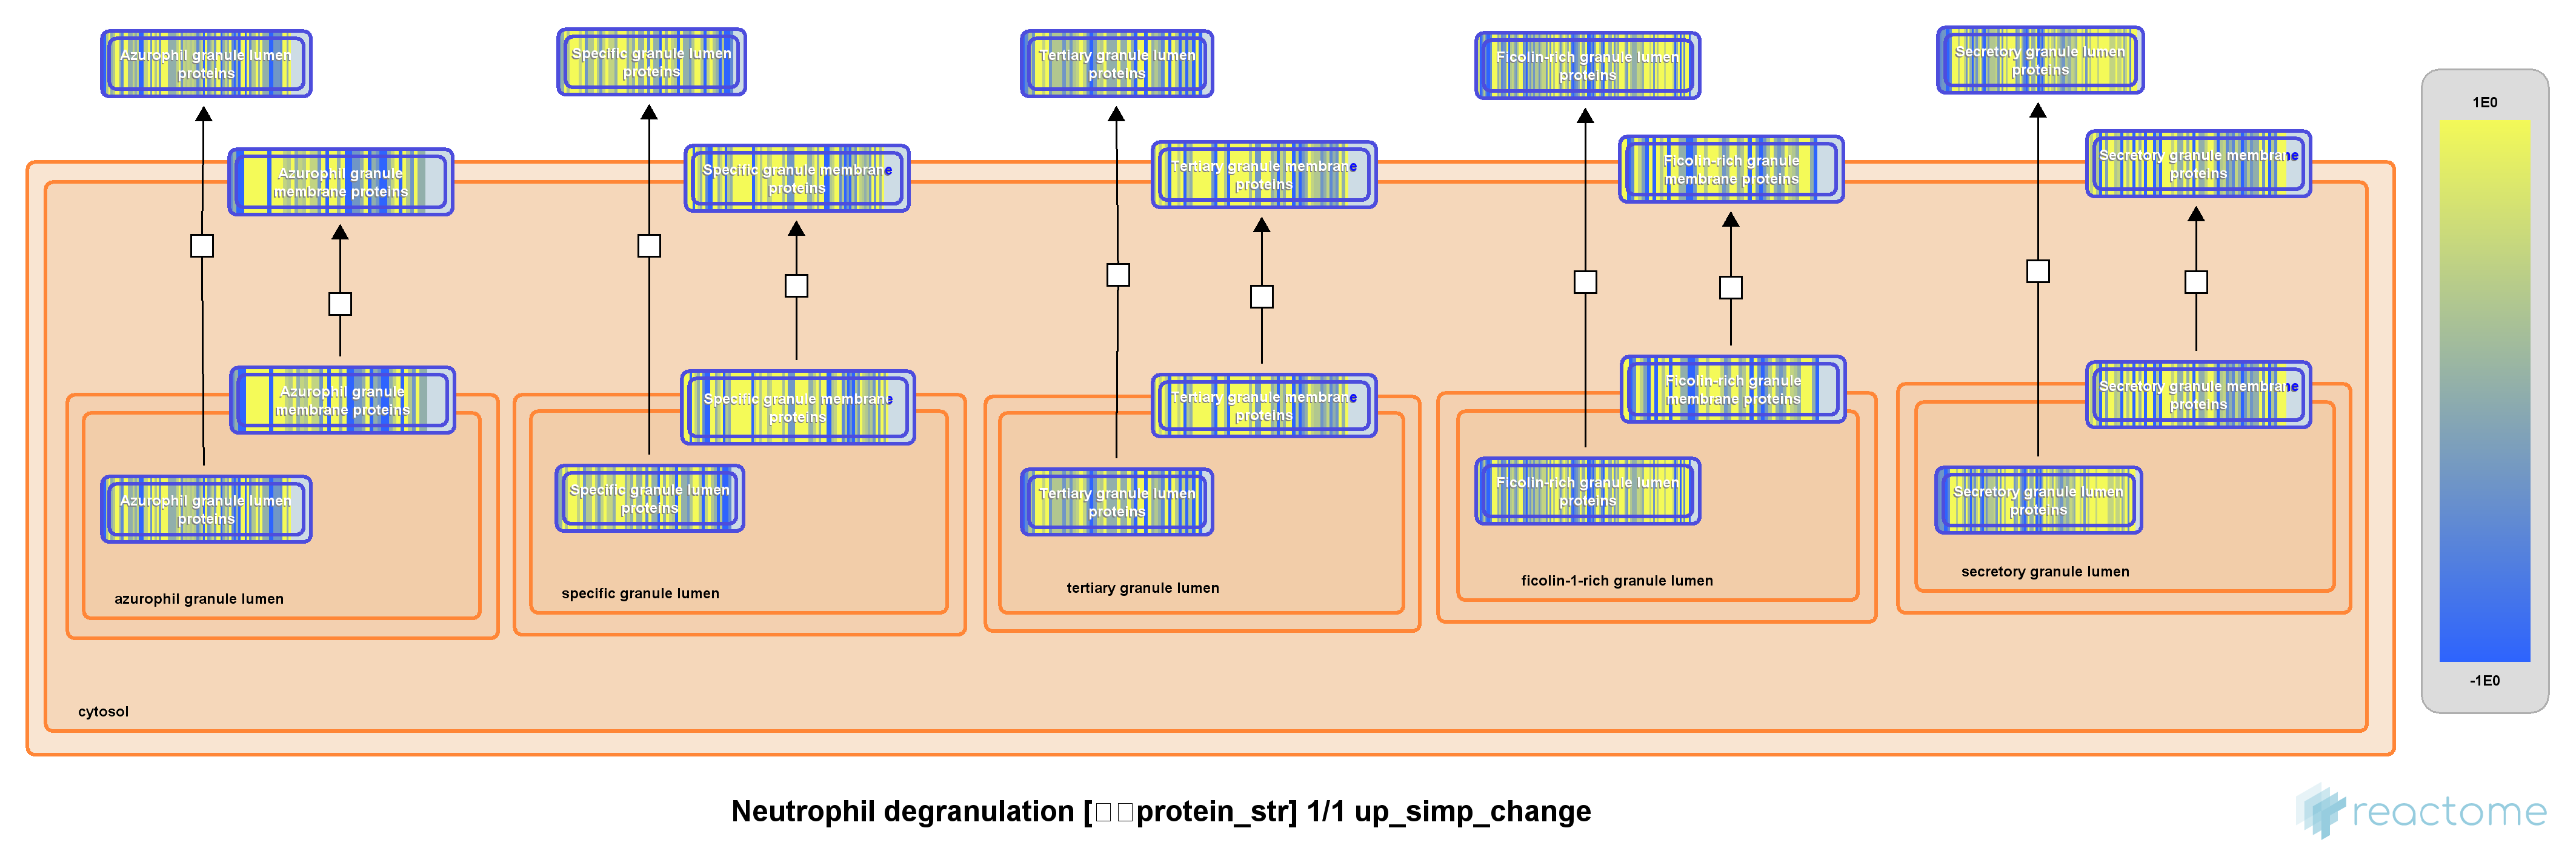

In [16]:
IPython.display.Image(up_image_path)

In [17]:
# Note that we're using expression_data, not all_expression_data; the former has
# only proteins where reject_null

down_image_path, down_url = pathway_overlay_wrapper(neutro_pathway_id, expression_data, enrichment_data, "down")

In [18]:
IPython.display.HTML(f'<a href={down_url}>{down_url}</a>')

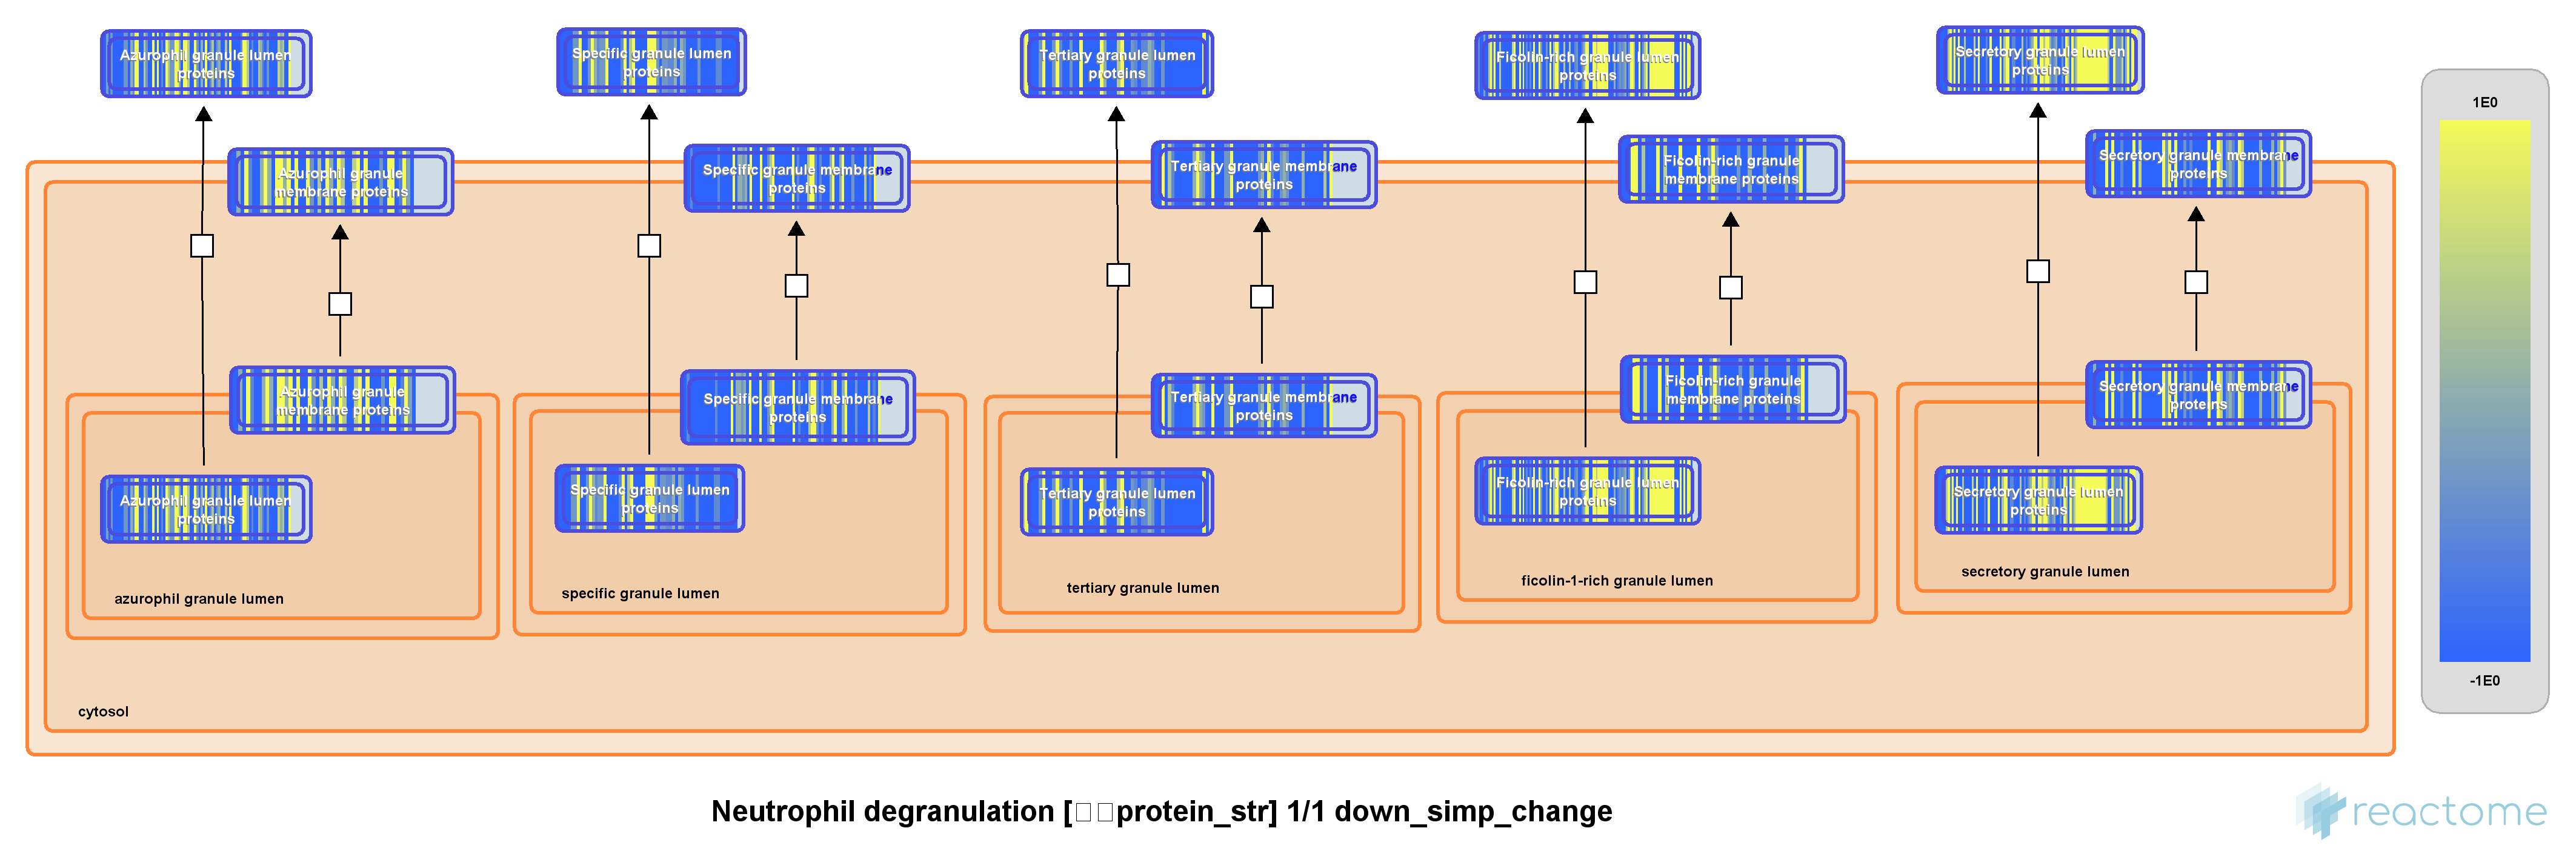

In [19]:
IPython.display.Image(down_image_path)

## Figure 4: Distribution of tumor stage in each cancer
Since neutrophil degranulation is associated with tumor progression, we want to check that it's not just up in cohorts with more high stage tumors, and down in cohorts with more low stage tumors.

In [20]:
cc = cptac.Ccrcc(no_internet=True)
co = cptac.Colon(no_internet=True)
en = cptac.Endometrial(no_internet=True)
gb = cptac.Gbm(no_internet=True)
hn = cptac.Hnscc(no_internet=True)
ls = cptac.Lscc(no_internet=True)
lu = cptac.Luad(no_internet=True)
ov = cptac.Ovarian(no_internet=True)

cptac warning: The GBM dataset is under publication embargo until March 01, 2021. CPTAC is a community resource project and data are made available rapidly after generation for community research use. The embargo allows exploring and utilizing the data, but analysis may not be published until after the embargo date. Please see https://proteomics.cancer.gov/data-portal/about/data-use-agreement or enter cptac.embargo() to open the webpage for more details. (/home/caleb/anaconda3/envs/dev/lib/python3.7/site-packages/ipykernel_launcher.py, line 4)


cptac warning: The HNSCC data is currently strictly reserved for CPTAC investigators. Otherwise, you are not authorized to access these data. Additionally, even after these data become publicly available, they will be subject to a publication embargo (see https://proteomics.cancer.gov/data-portal/about/data-use-agreement or enter cptac.embargo() to open the webpage for more details). (/home/caleb/anaconda3/envs/dev/lib/python3.7/site-packages/ipykernel_launcher.py, line 5)


cptac warning: The LSCC data is currently strictly reserved for CPTAC investigators. Otherwise, you are not authorized to access these data. Additionally, even after these data become publicly available, they will be subject to a publication embargo (see https://proteomics.cancer.gov/data-portal/about/data-use-agreement or enter cptac.embargo() to open the webpage for more details). (/home/caleb/anaconda3/envs/dev/lib/python3.7/site-packages/ipykernel_launcher.py, line 6)


cptac warning: The LUAD dataset is under publication embargo until July 01, 2020. CPTAC is a community resource project and data are made available rapidly after generation for community research use. The embargo allows exploring and utilizing the data, but analysis may not be published until after the embargo date. Please see https://proteomics.cancer.gov/data-portal/about/data-use-agreement or enter cptac.embargo() to open the webpage for more details. (/home/caleb/anaconda3/envs/dev/lib/python3.7/site-packages/ipykernel_launcher.py, line 7)


In [21]:
stage_df = pd.DataFrame()

In [22]:
cc_stage = cc.get_clinical()["tumor_stage_pathological"].\
    dropna().\
    str.rsplit(" ", n=1, expand=True)[1].\
    rename("tumor_stage").\
    reset_index(drop=False).\
    assign(cancer_type="ccrcc")

stage_df = stage_df.append(cc_stage)

In [23]:
co_stage = co.get_clinical()["Stage"].\
    dropna().\
    str.rsplit(" ", n=1, expand=True)[1].\
    rename("tumor_stage").\
    reset_index(drop=False).\
    assign(cancer_type="colon")

stage_df = stage_df.append(co_stage)

In [24]:
en_stage = en.get_clinical()["tumor_Stage-Pathological"].\
    dropna().\
    str.rsplit(" ", n=1, expand=True)[1].\
    rename("tumor_stage").\
    reset_index(drop=False).\
    assign(cancer_type="endometrial")

stage_df = stage_df.append(en_stage)

In [25]:
# GBM: All tumors are stage IV
gb_stage = pd.Series("IV", gb.get_clinical().index).\
    rename("tumor_stage").\
    reset_index(drop=False).\
    assign(cancer_type="gbm")

gb_stage
stage_df = stage_df.append(gb_stage)

In [26]:
hn_stage = hn.get_clinical()["patho_staging_curated"].\
    dropna().\
    str.rsplit(" ", n=1, expand=True)[1].\
    rename("tumor_stage").\
    reset_index(drop=False).\
    assign(cancer_type="hnscc")

stage_df = stage_df.append(hn_stage)

In [27]:
ls_stage = ls.get_clinical()["Stage"]
ls_stage = ls_stage.\
    rename("tumor_stage").\
    where(
        cond=~(ls_stage.dropna().str.endswith("A") | ls_stage.dropna().str.endswith("B")),
        other=ls_stage.str[:-1]).\
    where(
        cond=~(ls_stage.dropna().str.endswith("A 3")),
        other=ls_stage.dropna().str[:-3]
    ).\
    reset_index(drop=False).\
    assign(cancer_type="lscc")

stage_df = stage_df.append(ls_stage)

In [28]:
lu_stage = lu.get_clinical()["Stage"]
lu_stage = lu_stage.\
    rename("tumor_stage").\
    where(
        cond=~(lu_stage.dropna().str.endswith("A") | lu_stage.dropna().str.endswith("B")),
        other=lu_stage.str[:-1]).\
    replace({
        "1": "I",
        "2": "II",
        "3": "III"}).\
    reset_index(drop=False).\
    assign(cancer_type="luad")

stage_df = stage_df.append(lu_stage)

In [29]:
ov_stage = ov.get_clinical()["Tumor_Stage_Ovary_FIGO"]
ov_stage = ov_stage.\
    rename("tumor_stage").\
    where(
        cond=~(ov_stage.dropna().str.endswith("A") | 
               ov_stage.dropna().str.endswith("B") | 
               ov_stage.dropna().str.endswith("C")),
        other=ov_stage.str[:-1]).\
    drop(ov_stage[ov_stage == "Not Reported/ Unknown"].index).\
    reset_index(drop=False).\
    assign(cancer_type="ovarian")

stage_df = stage_df.append(ov_stage)

In [30]:
# Drop NaN samples
stage_df = stage_df.dropna()

# Drop normal samples (to avoid duplicate counts)
stage_df = stage_df[~stage_df["Patient_ID"].str.endswith(".N")]

In [31]:
# Join in whether neutrophil expression is up or down in tumor
neutro_expr = enrichment_data.loc[
    enrichment_data["pathway_id"] == neutro_pathway_id, 
    ["cancer_type", "name", "pathway_id", "mean_expr"]]

neutro_expr

,cancer_type,name,pathway_id,mean_expr
0,ccrcc,Neutrophil degranulation,R-HSA-6798695,0.233503
1,colon,Neutrophil degranulation,R-HSA-6798695,-0.134831
2,endometrial,Neutrophil degranulation,R-HSA-6798695,0.288515
3,gbm,Neutrophil degranulation,R-HSA-6798695,0.166227
4,hnscc,Neutrophil degranulation,R-HSA-6798695,0.133159
5,lscc,Neutrophil degranulation,R-HSA-6798695,-0.407595
6,luad,Neutrophil degranulation,R-HSA-6798695,-0.410000
7,ovarian,Neutrophil degranulation,R-HSA-6798695,-0.303754


In [32]:
stage_df = stage_df.merge(
    right=neutro_expr,
    how="left",
    left_on="cancer_type",
    right_on="cancer_type",
    validate="many_to_one")

In [33]:
# Make plots
alt.Chart(stage_df).mark_bar().encode(
    x=alt.X(
        "tumor_stage:N",
        axis=alt.Axis(
            labelAngle=0,
            labelFontSize=14,
            title=""
        )
    ),
    y=alt.Y(
        "count():Q",
        axis=alt.Axis(
            title="Count",
            titleFontSize=12
        )
    ),
    color=alt.Color(
        "mean_expr:Q",
        scale=alt.Scale(
            scheme="blueorange",
            domain=[-1, 1]
        ),
        legend=alt.Legend(
            title=["Neutrophil degranulation:", "Mean pathway expression", "in tumor"]
        )
    ),
    column=alt.Column(
        "cancer_type:N",
        title="Tumor stage distributions",
    )
).properties(
    width=65
).configure_header(
    titleFontSize=12
)

alt.Chart(...)

In [34]:
# Ask Sam: Is this idea of "mean pathway expression" 
# really valid? What if in reality, though we can't
# measure it, some proteins' magnitude of expression 
# change is a lot greater, so they should actually
# have greater weight in the mean calculation, and
# thus might alter the overall statistic for the
# pathway?

## Aside: What is the mean_expr value from Reactome?
Checking if it's just the mean of the expression values for all member entities.

Nope, it's not quite. But it always has the same sign as the mean of the expression values for all member entities, and each pathway is given the same rank regardless of which we sort by.

In [35]:
pathways = []
cancers = []
mean_exprs = []
mean_simps = []

for pathway_id in enrichment_data["pathway_id"].unique():
    
    prots = ut.search_reactome_proteins_in_pathways(pathway_id)
    
    for cancer_type in expression_data["cancer_type"].unique():
        
        mean_simp = expression_data.\
            loc[
                expression_data["protein_str"].isin(prots["member"]) & 
                (expression_data["cancer_type"] == cancer_type),
                "simplified_change"
            ].\
            mean()
        
        mean_expr = enrichment_data.\
            loc[
                (enrichment_data["pathway_id"] == pathway_id) &
                (enrichment_data["cancer_type"] == cancer_type),
                "mean_expr"
            ].iloc[0]
        
        assert((mean_simp > 0) == (mean_expr > 0))
        
        pathways.append(pathway_id)
        cancers.append(cancer_type)
        mean_exprs.append(mean_expr)
        mean_simps.append(mean_simp)
        
df = pd.DataFrame({
    "pathway_id": pathways,
    "cancer_type": cancers,
    "mean_expr": mean_exprs,
    "mean_simp": mean_simps
})

In [36]:
df.sort_values(by=["pathway_id", "cancer_type", "mean_expr"]).equals(
    df.sort_values(by=["pathway_id", "cancer_type", "mean_simp"]))

True

In [37]:
df

,pathway_id,cancer_type,mean_expr,mean_simp
0,R-HSA-6798695,ccrcc,0.233503,0.293194
1,R-HSA-6798695,colon,-0.134831,-0.062295
2,R-HSA-6798695,endometrial,0.288515,0.355263
3,R-HSA-6798695,gbm,0.166227,0.292683
4,R-HSA-6798695,hnscc,0.133159,0.203488
5,R-HSA-6798695,lscc,-0.407595,-0.441096
6,R-HSA-6798695,luad,-0.410000,-0.468493
7,R-HSA-6798695,ovarian,-0.303754,-0.292776
8,R-HSA-6791226,ccrcc,0.699422,0.950000
9,R-HSA-6791226,colon,0.771429,0.963855
